# Joint plot

## Table of Contents

1. [Default Presentation of Joint Plot](#default)

2. [Change Geom Types](#change-geom)

3. [Geometries Customization](#geom-customization)

4. [Marginal Layers Customization](#marginal-customization)

5. [Grouping](#grouping)

6. [Additional Layer](#additional_layer)

In [1]:
import pandas as pd

from lets_plot.bistro import *
from lets_plot import *


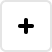
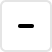
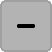
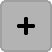
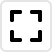
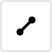
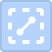
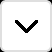
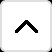
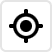
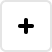
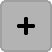
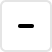
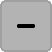
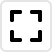
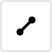
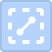
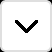
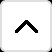
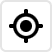

In [2]:
LetsPlot.setup_html()

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/JetBrains/lets-plot-docs/master/data/iris.csv")
print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<a id="default"></a>

## 1. Default Presentation of Joint Plot

In the simplest case, assign `x` and `y` to create a scatterplot (using `geom_point()`) with marginal histograms (using `geom_histogram()`).

In [4]:
joint_plot(df, "petal_length", "petal_width")

<a id="change-geom"></a>

## 2. Change Geom Types

Besides the points there are another two types of geoms: `tile` and `density2d(f)`.

In [5]:
joint_plot(df, "petal_length", "petal_width", geom='tile')

In [6]:
joint_plot(df.dropna(), "petal_length", "petal_width", color_by="species", geom='density2d')

<a id="geom-customization"></a>

## 3. Change Geom Parameters

Use additional parameters for better customization: `color`, `size`, `alpha`, etc.

In [7]:
joint_plot(df, "petal_length", "petal_width", color="#756bb1", size=8, alpha=.5, se=False)

<a id="marginal-customization"></a>

## 4. Marginal Layers Customization

`marginal` parameter is a shortcut for the `ggmarginal()` layer.

In [8]:
joint_plot(df, "petal_length", "petal_width", color="black", marginal="box:lb:.03,hist:t:.4,hist:r") + \
    ggmarginal("tr", layer=geom_area(stat='density', color="magenta", fill="magenta", alpha=.1)) + \
    theme(axis_line_x='blank', axis_line_y='blank')

<a id="grouping"></a>

## 5. Grouping

The `color_by` parameter sets the mapping to the fill and color aesthetics.

In [9]:
joint_plot(df, "petal_length", "petal_width", color_by="species", marginal="hist:tr")

<a id="additional_layer"></a>

## 6. Additional Layer

Add any other layer that supports `x` and `y` aesthetics (e.g. points layer with the `geom_point()` function).

In [10]:
joint_plot(df, "petal_length", "petal_width", geom='density2df', \
           color="#993404", alpha=1/3, reg_line=False) + \
    geom_point(size=5, shape=21, color="#993404", fill="#ffffd4") + \
    scale_fill_gradient(low="#d95f0e", high="#fff7bc")